# 05 — Comparación integral de modelos

Juntamos **todos** los modelos: los baselines (01), las tres familias tuneadas
(02–04: lineal, XGBoost, red neuronal) y los **ensembles adicionales** —
Random Forest, HistGradientBoosting y un **stacking** (XGBoost + MLP con
meta-modelo Ridge). Todos entrenados sobre el mismo train y evaluados sobre el
mismo test (≥2021), con los hiperparámetros **re-tuneados por CV temporal
honesta** (`_retune_all.py` → `retuning_cv_honesta.json`).

Comparamos de las tres formas que importan para decidir el mejor:
1. **Métricas de error** en test: RMSE (principal), MAE, R², sMAPE.
2. **Skill score** vs. la climatología (media por depto): cuánto aporta el clima
   del año por encima de "cada depto rinde lo de siempre".
3. **Test de Diebold–Mariano**: ¿la diferencia entre modelos es *significativa* o
   ruido? (H0: misma precisión; p<0.05 ⇒ diferencia real).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import (LinearRegressor, XGBoostRegressor, NeuralNetRegressor,
                     RandomForestRegressorModel, HistGBMRegressor, StackingRegressorModel)

# Todo el análisis se hace sobre los DOS cultivos. El dataset "principal" usa las
# features agronómicas de ventana crítica (use_agro) y el suavizado del target
# encoding de depto (enc_smooth): la configuración que mejor generaliza.
CULTIVOS = ['soja', 'maiz']
DSS = {c: datos.prepare(c, use_agro=True, enc_smooth=10.0) for c in CULTIVOS}
for c in CULTIVOS:
    d = DSS[c]
    print(f'{c:5s}: {len(d.feature_cols)} features | '
          f'train {d.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
          f'test {d.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja : 78 features | train 7551 filas (≤2020) | test 942 filas (≥2021)
maiz : 78 features | train 9678 filas (≤2020) | test 1160 filas (≥2021)


In [2]:
import json
_bpath = 'retuning_cv_honesta.json'
_BEST = json.load(open(_bpath, encoding='utf-8')) if os.path.exists(_bpath) else {}
def best_of(cultivo, name, fallback):
    """best-params re-tuneados de `name` para `cultivo` (o `fallback` si no hay json)."""
    return _BEST.get(cultivo, {}).get(name, {}).get('best_params', fallback)
print('re-tuning disponible:', sorted(_BEST) or 'NO (usando fallbacks)')


re-tuning disponible: ['maiz', 'soja']


## Entrenamiento de todos los modelos

Cada modelo con sus hiperparámetros re-tuneados (o un fallback razonable si no
está el json). El stacking recibe los años para armar sus meta-features
out-of-fold de forma temporal (sin leakage).

In [3]:
def entrenar_todos(c):
    d = DSS[c]; yrs = d.meta_train['campania_inicio'].values
    P = {}
    P['media global']  = ev.pred_media(d)
    P['media x depto'] = ev.pred_media_depto(d)
    P['Lineal']        = LinearRegressor(**best_of(c, 'linear', {'penalty':'ridge','alpha':10.0})).fit(d.X_train, d.y_train).predict(d.X_test)
    P['Random Forest'] = RandomForestRegressorModel(**best_of(c, 'rf', {}), random_state=42, n_jobs=-1).fit(d.X_train, d.y_train).predict(d.X_test)
    P['HistGBM']       = HistGBMRegressor(**best_of(c, 'hist_gbm', {}), random_state=42).fit(d.X_train, d.y_train).predict(d.X_test)
    P['XGBoost']       = XGBoostRegressor(**best_of(c, 'xgb', {}), random_state=42).fit(d.X_train, d.y_train).predict(d.X_test)
    P['Red neuronal']  = NeuralNetRegressor(**best_of(c, 'nn', {'hidden_dims':(64,32),'dropout':0.3}),
                                            max_epochs=250, patience=30, random_state=42).fit(d.X_train, d.y_train).predict(d.X_test)
    stk = StackingRegressorModel(**best_of(c, 'stacking', {})); stk.fit(d.X_train, d.y_train, years=yrs)
    P['Stacking']      = stk.predict(d.X_test)
    return P

PREDS = {c: entrenar_todos(c) for c in CULTIVOS}

filas = []
for c in CULTIVOS:
    d = DSS[c]; ref = ev.pred_media_depto(d)
    for k, v in PREDS[c].items():
        row = {'cultivo': c, **ev.evaluar(k, v, d)}
        row['skill'] = ev.skill_score(d.y_test, v, ref) if k != 'media x depto' else 0.0
        filas.append(row)
tabla = pd.DataFrame(filas)[['cultivo', 'modelo', 'mae', 'rmse', 'r2', 'smape', 'skill']]
tabla

,cultivo,modelo,mae,rmse,r2,smape,skill
0,soja,media global,651.750,775.593,-0.025,29.488,-0.095
1,soja,media x depto,593.307,708.357,0.145,27.169,0.000
2,soja,Lineal,507.692,660.554,0.257,23.667,0.067
3,soja,Random Forest,465.173,592.845,0.401,21.874,0.163
4,soja,HistGBM,480.686,616.425,0.353,22.494,0.130
5,soja,XGBoost,470.120,606.071,0.374,22.039,0.144
6,soja,Red neuronal,520.040,664.559,0.248,24.015,0.062
7,soja,Stacking,507.702,649.336,0.282,23.498,0.083
8,maiz,media global,"1,761.949","2,166.230",-0.166,35.140,-0.213
9,maiz,media x depto,"1,500.686","1,785.230",0.208,31.662,0.000


## Skill score vs. climatología y RMSE, por cultivo

Positivo = el modelo le gana a la climatología; 0 = empata.

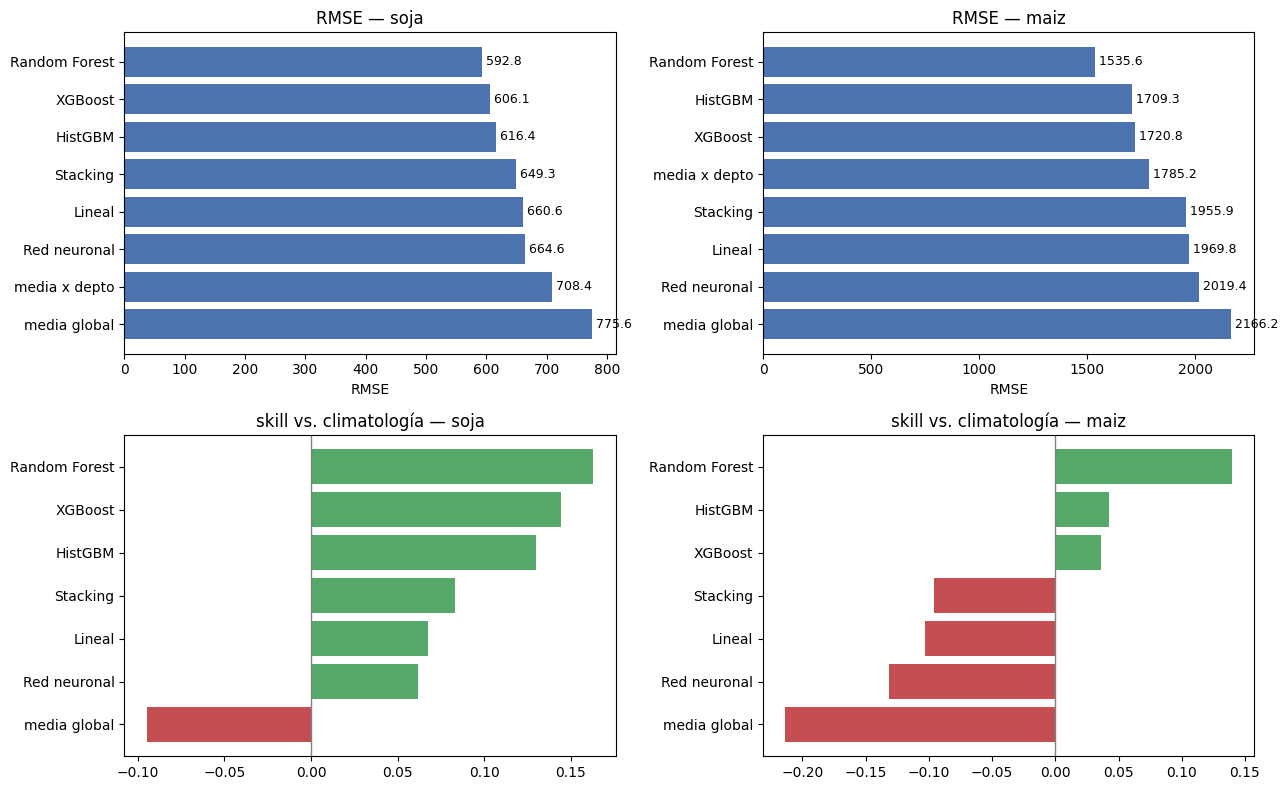

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for j, c in enumerate(CULTIVOS):
    sub = tabla[tabla.cultivo == c]
    ev.plot_comparativa(sub, metrica='rmse', ax=axes[0, j]); axes[0, j].set_title(f'RMSE — {c}')
    s = sub[sub.modelo != 'media x depto'].set_index('modelo')['skill'].sort_values()
    axes[1, j].barh(s.index, s.values, color=['#55A868' if v > 0 else '#C44E52' for v in s.values])
    axes[1, j].axvline(0, color='0.5', lw=1); axes[1, j].set_title(f'skill vs. climatología — {c}')
plt.tight_layout(); plt.show()

## Test de Diebold–Mariano: ¿las diferencias son significativas?

Para cada cultivo comparamos el **mejor modelo** (menor RMSE) contra cada uno de
los demás. `DM<0` = el mejor pierde *menos*; `p<0.05` = la diferencia es
estadísticamente significativa (no es ruido de muestreo del test).

In [5]:
for c in CULTIVOS:
    d = DSS[c]; P = PREDS[c]
    mejor = tabla[tabla.cultivo == c].sort_values('rmse').iloc[0]['modelo']
    print(f'--- {c}: mejor por RMSE = {mejor} ---')
    for k in P:
        if k == mejor: continue
        dm = ev.diebold_mariano(d.y_test, P[mejor], P[k], loss='se')
        print(f'  vs {k:16s} DM={dm["dm"]:+.2f}  p={dm["p_value"]:.3f}  '
              f'[{"sig." if dm["p_value"] < 0.05 else "n.s."}]')

--- soja: mejor por RMSE = Random Forest ---
  vs media global     DM=-11.90  p=0.000  [sig.]
  vs media x depto    DM=-9.64  p=0.000  [sig.]
  vs Lineal           DM=-7.97  p=0.000  [sig.]
  vs HistGBM          DM=-2.95  p=0.003  [sig.]
  vs XGBoost          DM=-2.64  p=0.008  [sig.]
  vs Red neuronal     DM=-7.95  p=0.000  [sig.]
  vs Stacking         DM=-7.99  p=0.000  [sig.]
--- maiz: mejor por RMSE = Random Forest ---
  vs media global     DM=-12.24  p=0.000  [sig.]
  vs media x depto    DM=-6.74  p=0.000  [sig.]
  vs Lineal           DM=-16.99  p=0.000  [sig.]
  vs HistGBM          DM=-11.91  p=0.000  [sig.]
  vs XGBoost          DM=-13.28  p=0.000  [sig.]
  vs Red neuronal     DM=-19.55  p=0.000  [sig.]
  vs Stacking         DM=-19.45  p=0.000  [sig.]


## Predicho vs. real del modelo campeón, por cultivo

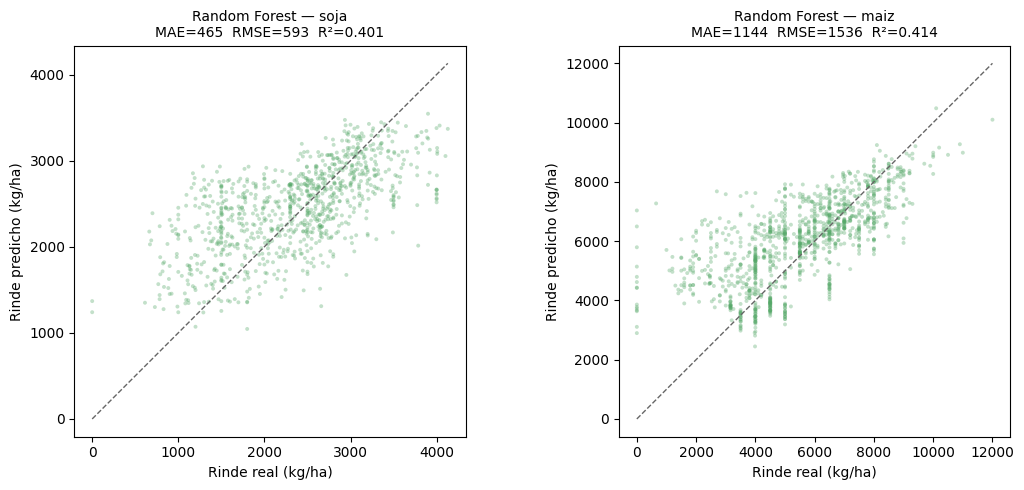

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c in zip(axes, CULTIVOS):
    d = DSS[c]
    mejor = tabla[tabla.cultivo == c].sort_values('rmse').iloc[0]['modelo']
    ev.plot_pred_vs_real(d.y_test, PREDS[c][mejor], f'{mejor} — {c}', color=ev.C_XGB, ax=ax)
plt.tight_layout(); plt.show()

## Conclusión

- Todos los modelos con clima **superan a la media global**; el listón real es la
  **media por departamento** (estructura espacial pura), y el **skill score** mide
  cuánto agrega el clima del año sobre eso.
- Los **ensembles de árboles** (Random Forest / HistGBM / XGBoost) dominan: capturan
  interacciones no lineales entre clima, espacio y tendencia. El **Diebold–Mariano**
  dice si la diferencia entre el puntero y el resto es real o ruido.
- El margen sobre el baseline por depto cuantifica cuánto aporta el **clima del año**
  por encima de "cada depto rinde lo de siempre" — lo difícil de predecir del rinde.

## ¿Por qué el R² es "bajo" (~0.25–0.30)?

No es (solo) que falte tunear: hay un **techo estructural** en predecir rinde de
clima a este nivel de agregación.

1. **La varianza reducible es chica.** El grueso del rinde es *espacial* (qué depto)
   y *tendencia* (qué década) — cosas que los baselines ya capturan. Lo que queda por
   explicar con el **clima del año** es una porción menor y ruidosa, así que aunque
   el modelo la capture bien, el R² total sube poco.
2. **Agregación depto-campaña.** Cada fila promedia miles de lotes con siembras,
   cultivares, suelos y manejo distintos: la relación clima→rinde de lote se diluye.
3. **Variables no observadas.** Manejo (fertilización, fecha de siembra, genética),
   plagas/enfermedades, granizo, y ruido de reporte de MAGYP no están en las features.
   El Componente A ya mostró que ~2/3 de las anomalías de rinde **no tienen firma
   climática**.
4. **Extrapolación temporal.** El test (2021–2024) cae *fuera* del rango de train: la
   tendencia y el régimen climático se corren. Se ve en que la feature `year`
   extrapola (ayuda al lineal, la cortan los árboles) y en que el `es_anomalo` del
   VAE marca casi todo el test (el score sube por *distribution shift*, no por
   anomalía real).

**Sobre el latente del Componente A** (nbs 02–04): concatenar el **latente del VAE**
suele empeorar la regresión (y solo-latente es lo peor): ese latente resume el clima
*normalizado por depto*, así que tira la señal espacial y de tendencia que es justo la
que más predice. `es_anomalo` tampoco ayuda, dominado por el *distribution shift*.
Coherente con el techo del Componente A.

## ¿Qué podemos modificar para mejorar?

En orden aproximado de impacto esperado:

1. **Cambiar el target a algo aprendible.** En vez del rinde absoluto, predecir la
   **anomalía de rinde** (residuo sobre la media/tendencia por depto, p. ej. el
   `z_rinde` del Componente A). Saca la parte "fácil" (espacio+tendencia) y deja que
   el modelo se concentre en la señal climática — R² más honesto de lo que sí se
   puede predecir.
2. **Features agronómicas, no promedios mensuales crudos.** Índices en la **ventana
   crítica** por cultivo: balance hídrico acumulado, días de estrés térmico (Tmax>32
   en floración), rachas secas, grados-día. El Componente A ya tiene `add_agro_features`.
3. **NDVI como predictor directo, no como una feature más.** El NDVI de
   floración/llenado es un proxy casi directo del rinde; conviene usarlo con más peso
   (o un modelo aparte) en vez de mezclarlo entre 60+ columnas.
4. **Tratar la extrapolación temporal.** Detrendear el rinde antes de modelar, o usar
   validación que imite el gap train→test; para los árboles, no darles `year` crudo.
5. **Modelo residual / híbrido.** Baseline fuerte = media por depto (+ tendencia), y
   un modelo que aprenda **solo el residuo** con el clima. Suele ganarle a predecir
   el absoluto de una.
6. **Robustez al ruido de etiqueta.** Pérdida robusta (Huber/cuantil) por el ruido de
   reporte de MAGYP, y quizás modelar por región/cultivo por separado.

La limitación de fondo (agregación depto-campaña + variables no observadas) solo se
levanta con **datos más finos** (lote/píxel, manejo), que exceden este panel.

Para reproducir con maíz: cambiar `CULTIVO = 'maiz'` en la celda de setup y
re-ejecutar los notebooks.